# Assignment 2 – Zero-Shot Image Classification with Transformers

In this assignment, you will apply a pre-trained vision–language transformer (e.g. CLIP) to perform **zero-shot** classification on the Fashion-MNIST dataset—classifying each image without any task-specific training. You will build on the concepts from Assignment 1 by comparing this “off-the-shelf” approach to the CNN you previously trained.

You will:
1. **Load** the Fashion-MNIST images using PyTorch instead of Keras.
2. **Run a zero-shot baseline** with simple text prompts to set a performance reference.
3. **Engineer improved prompts** and measure the resulting accuracy gains.
4. **Visualise image embeddings** with UMAP to inspect class separability.
5. **Conduct one mini-experiment** of your choice.
6. **Summarise findings** and reflect on strengths and weaknesses of zero-shot transformers versus a trained CNN.

# 1. Loading the Fashion-MNIST Dataset

As in assignment 1, we'll load the Fashion-MNIST dataset, but this time using `torchvision.datasets` to ensure compatibility with the `transformers` library. We will also load our model and processor from the `transformers` library.

The transformers library allows us to use pre-trained models like CLIP, which can perform zero-shot classification by leveraging the text prompts we provide. There are two key objects we will use: the `CLIPModel` for the model itself and the `CLIPProcessor` for preparing our images and text prompts.

Since we are not actually training a model in this assignment, we will set the CLIP model to evaluation mode. If the model is designed to utilize features like dropout or batch normalization, setting it to evaluation mode ensures that these features behave correctly during inference (prediction). Setting the model to evaluaton mode also tells PyTorch that we don't have to compute gradients, which can save memory and speed up inference.

In order to speed up processing, we will also move the model to an "accelerator" if available. This is typically a GPU, but modern MacBooks also have an "Apple Silicon" accelerator that can be used for inference, called MPS (Metal Performance Shaders). If you are using a MacBook with Apple Silicon, you can use the MPS device for faster processing.

In [1]:
# Uncomment and run if required
#!pip install transformers torchvision torch accelerate

In [2]:
from transformers import CLIPModel, CLIPProcessor
import torch

clip_model_name = "openai/clip-vit-base-patch32"
clip_model     = CLIPModel.from_pretrained(clip_model_name)
clip_processor = CLIPProcessor.from_pretrained(clip_model_name, use_fast=False)

# Set model to evaluation mode, as we are not training it
clip_model.eval()

# Check for accelerators
device = "cpu" # Default to CPU
if torch.cuda.is_available():
    device = "cuda" # Use GPU if available
elif torch.backends.mps.is_available():
    device = "mps"

clip_model.to(device)

print(f"Using device: {device}")

2026-07-24 20:18:05.663826: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-24 20:18:06.766620: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-24 20:18:08.684232: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-24 20:18:08.684833: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not 

Using device: cpu


Now we are ready to load the testing set from Fashion-MNIST. We will use the `torchvision.datasets.FashionMNIST` class to load the dataset. We do not need to apply any transformations to the images, as the `CLIPProcessor` ensures any input images are in the format that the model is trained on.

You should:

- [ ] Use the `torchvision.datasets.FashionMNIST` class to load the *test* split of the dataset. Documentation is available [here](https://pytorch.org/vision/stable/generated/torchvision.datasets.FashionMNIST.html).
- [ ] Create a PyTorch `DataLoader` to iterate over the dataset in batches. Use a batch size of 16 and set `shuffle=True` to randomise the order of the images. You will also need to supply the provided `collate_clip` function to the `DataLoader collate_fn` argument to ensure the images are processed correctly. Documentation for `DataLoader` is available [here](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader).

In [3]:
from torchvision import datasets
from torch.utils.data import DataLoader

CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

def collate_clip(batch):
    imgs, labels = zip(*batch) # Unzip the batch into images and labels
    proc = clip_processor(images=list(imgs),
                        return_tensors="pt",
                        padding=True) # Process images with CLIPProcessor
    # Send pixel_values to GPU/CPU now; labels stay on CPU for metrics
    return proc["pixel_values"].to(device), torch.tensor(labels)

test_dataset = datasets.FashionMNIST(root="./data", train=False, download=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=True, collate_fn=collate_clip)

If your code is correct, the following cell should show the first batch of images from the Fashion-MNIST dataset:

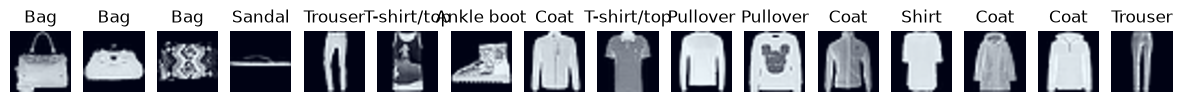

In [4]:
import matplotlib.pyplot as plt

# Display the first batch of images from `test_loader`

def show_batch(loader):
    images, labels = next(iter(loader))
    images = images.cpu()  # Move images to CPU for plotting
    # Renormalize to [0, 1] for visualization
    images = (images - images.min()) / (images.max() - images.min())
    _, axes = plt.subplots(1, len(images), figsize=(15, 5))
    for ax, img, label in zip(axes, images, labels):
        ax.imshow(img.permute(1, 2, 0))
        ax.set_title(CLASS_NAMES[label.item()])
        ax.axis('off')
    plt.show()

show_batch(test_loader)

We’re now ready to run our zero-shot classification baseline!

# Brief Introduction to Zero-Shot Classification

In Assignment 1, we followed the typical machine-learning pipeline: we trained a CNN on the Fashion-MNIST dataset, using labelled examples to update the model’s weights. While effective, that approach requires a curated, task-specific training set—a luxury you don’t always have in practice.

Zero-shot classification flips the script.  A large vision–language model (VLM) such as **CLIP** is first pre-trained on hundreds of millions of image–text pairs scraped from the web.  Because it learns *joint* visual–textual embeddings, the model can later solve new tasks simply by “measuring” how similar an image is to a **text prompt** that describes each candidate class—without seeing a single task-labelled example.

**How it works**  
1. Feed an image through CLIP’s vision encoder → **image feature**.  
2. Feed a textual prompt (e.g. “a photo of a sandal”) through CLIP’s text encoder → **text feature**.  
3. Compute cosine similarity between the image feature and every class’s text feature.  
4. Pick the class whose prompt is most similar.

For our first attempt, we’ll use the bare class names as prompts, e.g.:

- "T-shirt/top"
- "Trouser"

### You should:

- [ ] Build embeddings: use the `get_text_embeddings` helper function to create text embeddings for the class names.
- [ ] Run inference: use the `get_image_embeddings` helper function to create image embeddings.
- [ ] Compute cosine similarity: complete and use the `get_cosine_similarity` helper function to compute the cosine similarity between the image and text embeddings.
- [ ] Make predictions: use the `get_predictions` helper function to get the predicted class for each image in the batch.

Note that for normalized vectors like the ones we are using, cosine similarity is equivalent to the dot product. This means we can use the handy formula `cosine_similarity = vector_a @ vector_b.T` to compute the similarity between the image and text embeddings.

In [5]:
def get_text_embeddings(class_names: list[str]) -> torch.Tensor:
    """    Get text embeddings for the given class names using CLIP.
    Args:
        class_names (list[str]): List of class names to encode.
    Returns:
        torch.Tensor: Normalized text embeddings for the class names.
    """
    tokenized = clip_processor(text=class_names,
                               padding=True,
                               return_tensors="pt").to(device)
    
    with torch.no_grad():
        text_embeddings = clip_model.get_text_features(**tokenized)

    text_feats = text_embeddings / text_embeddings.norm(dim=-1, keepdim=True)

    return text_feats

def get_image_embeddings(images: torch.Tensor) -> torch.Tensor:
    """    Get image embeddings for the given images using CLIP.
    Args:
        images (torch.Tensor): Batch of images to encode.
    Returns:
        torch.Tensor: Normalized image embeddings for the images.
    """
    with torch.no_grad():
        image_embeddings = clip_model.get_image_features(pixel_values=images)

    image_feats = image_embeddings / image_embeddings.norm(dim=-1, keepdim=True)

    return image_feats

In [6]:
import numpy as np

def get_cosine_similarity(image_feats: torch.Tensor, text_feats: torch.Tensor) -> np.ndarray:
    """
    Compute cosine similarity between image features and text features.
    Args:
        image_feats (torch.Tensor): Image features of shape (N, D).
        text_feats (torch.Tensor): Text features of shape (M, D).
    Returns:
        numpy.ndarray: Cosine similarity matrix of shape (N, M), where N is the number of images and M is the number of text prompts.
    """
    image_feats = image_feats.cpu()  # Ensure image features are on CPU
    text_feats = text_feats.cpu()    # Ensure text features are on CPU

    # Compute cosine similarity, which is the dot product of normalized vectors
    return image_feats @ text_feats.T

def get_predictions(similarity: np.ndarray) -> np.ndarray:
    """
    Get predictions based on cosine similarity scores.
    Args:
        similarity (numpy.ndarray): Cosine similarity matrix of shape (N, M), where N is the number of images and M is the number of text prompts.
    Returns:
        numpy.ndarray: Predicted class indices for each image, shape (N,).
    """
    # Get the index of the maximum similarity for each image
    return similarity.argmax(axis=1).cpu().numpy()

With these functions complete, you are ready to run the zero-shot classification baseline. Complete the code to follow these steps:

- [ ] Build text embeddings for the class names using the `get_text_embeddings` function (this only needs to be done once).
- [ ] For each batch of images:
    - [ ] Get image embeddings using the `get_image_embeddings` function.
    - [ ] Compute cosine similarity between the image and text embeddings using the `get_cosine_similarity` function.
    - [ ] Save the predictions so that we can build a confusion matrix later.
- [ ] Report the accuracy of the predictions and the confusion matrix using the `accuracy_score` and `confusion_matrix` functions from `sklearn.metrics`.

zero-shot accuracy: 0.6240


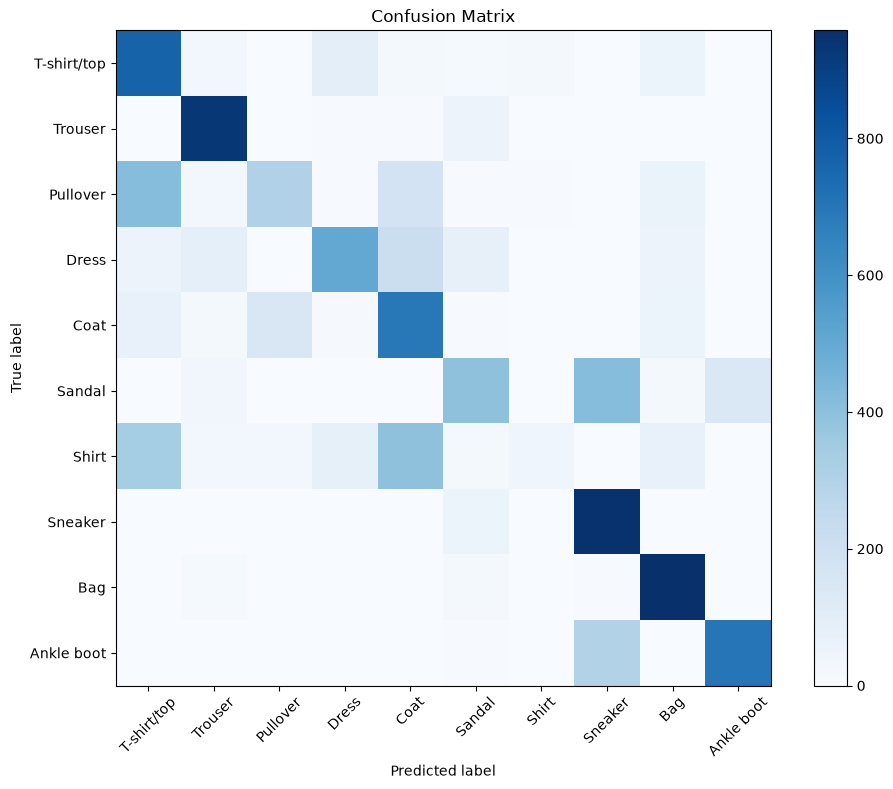

In [7]:
from sklearn.metrics import accuracy_score, confusion_matrix

y_true, y_pred = [], []

text_embeddings = get_text_embeddings(CLASS_NAMES)

for pixel_values, labels in test_loader:
    
# Report the accuracy of the predictions
    image_embeddings = get_image_embeddings(pixel_values)
    computed_cosine_similarity = get_cosine_similarity(image_embeddings, text_embeddings)
    predictions = get_predictions(computed_cosine_similarity)
    
    y_true.extend(labels.cpu().numpy())
    y_pred.extend(predictions)
    
# Report the confusion matrix

accuracy = accuracy_score(y_true, y_pred)
print(f'zero-shot accuracy: {accuracy:.4f}')

def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()
    
plot_confusion_matrix(y_true, y_pred, CLASS_NAMES)

Reflection: Consider the results. How does the performance of this zero-shot baseline compare to the CNN you trained in Assignment 1? What are the strengths and weaknesses of this approach?

## My Answer:
The Zero-shot model achieved 62.4% test accuracy. It's considerablly lower than the last CNN's accuracy trained in Assignment-1 which was 93.27%. The CNN model performed better because its weights were optimized specifically for Fashion-MNIST using labeled examples. 

The main strength of the zero-shot approach is that it requires no task-specific training and can immediately classify images using text descriptions. It also has the flexiblity of receiving altered candidate classes by modifying prompts. Its weaknesses are lower accuracy on this dataset, sensitivity to prompt wording, and difficulty distinguishing visually similar clothing categories.

## Improving Zero-Shot Classification with Prompt Engineering

In the previous section, we directly used the class names as text prompts for zero-shot classification. However, we can often improve performance by crafting more descriptive prompts that better capture the visual characteristics of each class. For example, instead of just "T-shirt/top", we could use "a photo of a T-shirt" or "a photo of a top". This additional context can help the model make more accurate predictions.

In this section, we will experiment with more detailed prompts for each class to see if we can improve the zero-shot classification performance. You should:

- [ ] Create a list of improved prompts for each class. For example, instead of just "T-shirt/top", you could use "a photo of a T-shirt" or "a photo of a top".
- [ ] Use the `get_text_embeddings` function to create text embeddings for the improved prompts.
- [ ] Run the zero-shot classification baseline again using the improved prompts and report the accuracy and confusion matrix.

Note: Take advantage of the confusion matrix above. If two classes are often confused, consider how you might improve the prompts to help the model distinguish them better.

The aim for this section is for you to improve the performance of the model. However, if you find that the performance does not improve significantly, you can still reflect on the process and consider how you might further refine the prompts with more effort.

improved_classes zero-shot accuracy: 0.6033


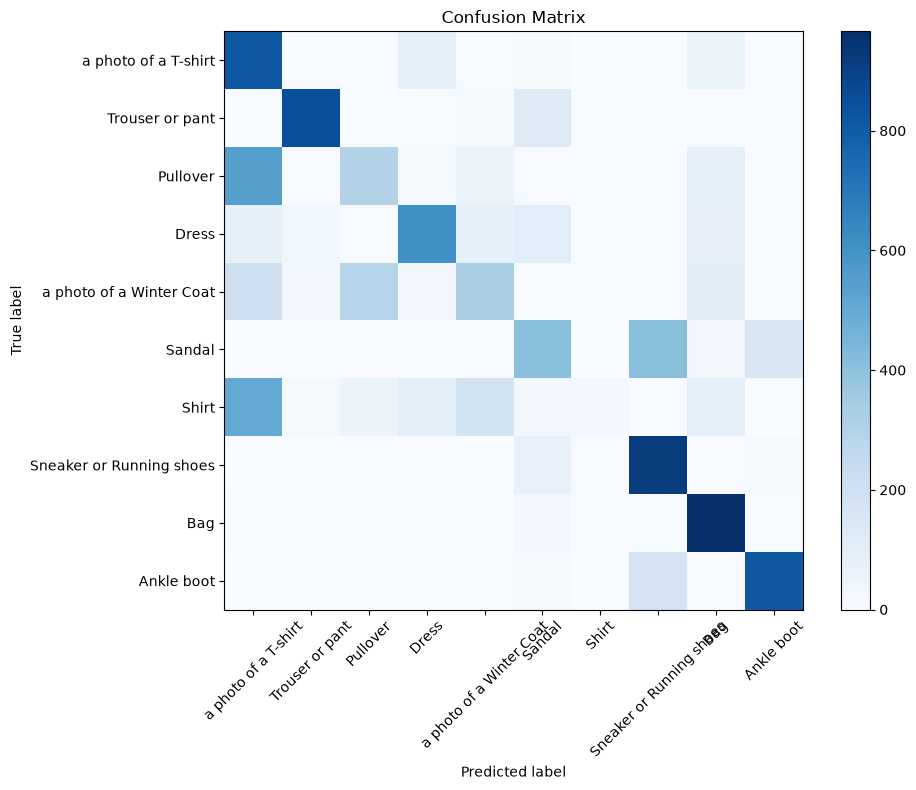

In [8]:
IMPROVED_CLASS_NAMES = [
    
    "a photo of a T-shirt",
    "Trouser or pant",
    "Pullover",
    "Dress",
    "a photo of a Winter Coat",
    "Sandal",
    "Shirt",
    "Sneaker or Running shoes",
    "Bag",
    "Ankle boot"
]

improved_classes_text_embeddings = get_text_embeddings(IMPROVED_CLASS_NAMES)

y_true, improved_classes_y_pred = [], []

for pixel_values, labels in test_loader:
    
# Report the accuracy of the predictions
    improved_classes_image_embeddings = get_image_embeddings(pixel_values)
    improved_classes_computed_cosine_similarity = get_cosine_similarity(improved_classes_image_embeddings, improved_classes_text_embeddings)
    improved_classes_predictions = get_predictions(improved_classes_computed_cosine_similarity)
    
    y_true.extend(labels.cpu().numpy())
    improved_classes_y_pred.extend(improved_classes_predictions)
    
# Report the confusion matrix

improved_classes_accuracy = accuracy_score(y_true, improved_classes_y_pred)
print(f'improved_classes zero-shot accuracy: {improved_classes_accuracy:.4f}')

plot_confusion_matrix(y_true, improved_classes_y_pred, IMPROVED_CLASS_NAMES)

Reflection: How did your detailed prompts affect the zero-shot classification performance? Did you see a significant improvement compared to the baseline? What insights did you gain about the model's understanding of the classes? Do you think that with more effort you could further improve the performance? If so, how?

## My Answer:
My detailed prompts made the zero-shot classification performance worse, this is specific to this dataset, though on other datasets it may behave differently. No, I saw a considerable drop in accuracy compared to the baseline (the details and justification are below). The insights I got is zero-shot classification works better if the name of the classes are less descriptive, it would provide its best performance when the class names are just one word for each class. I think more effort can improve the model performance only if it doesn't make each class name lengthy, and also in case of having similar classes like distinctive bags, if the specific name can be provided like a wallet, a backpack, a handbag each may be considered as a bag, but if we provide the model with alternative descriptions like instead of calling wallet, backpack and handbag all as a bag, instead providing a wallet is a wallet, a backpack is a backpack, and a handbag is a handbag. It would improve the performance of the model.

Details:

I changed the previous class names to these 

IMPROVED_CLASS_NAMES = [
    
    "a photo of a T-shirt",
    "Trouser or pant",
    "Pullover",
    "Dress",
    "a photo of a Winter Coat",
    "Sandal",
    "Shirt",
    "Sneaker or Running shoes",
    "Bag",
    "Ankle boot"
]

and the zero-shot accuracy reduced to: 0.6033

I think this was the response of the model because the classes became more descriptive. Maybe they shouldn't be!! One more effort would show that, if I make other classes descriptive as well and the model performance become worse. Then it shows long and wordy class descriptions worsens the model performance.

Let's make the class names wordy

IMPROVED_CLASS_NAMES = [

    "a photo of a T-shirt",
    "Trouser or pant",
    "a photo of a Pullover",
    "a photo of a Dress",
    "a photo of a Winter Coat",
    "a photo of a Sandal",
    "a photo of a Shirt",
    "a photo of a Sneaker or Running shoes",
    "a photo of a Bag",
    "a photo of an Ankle boot"
]

and then evaluate the model.

improved_classes zero-shot accuracy: 0.5294


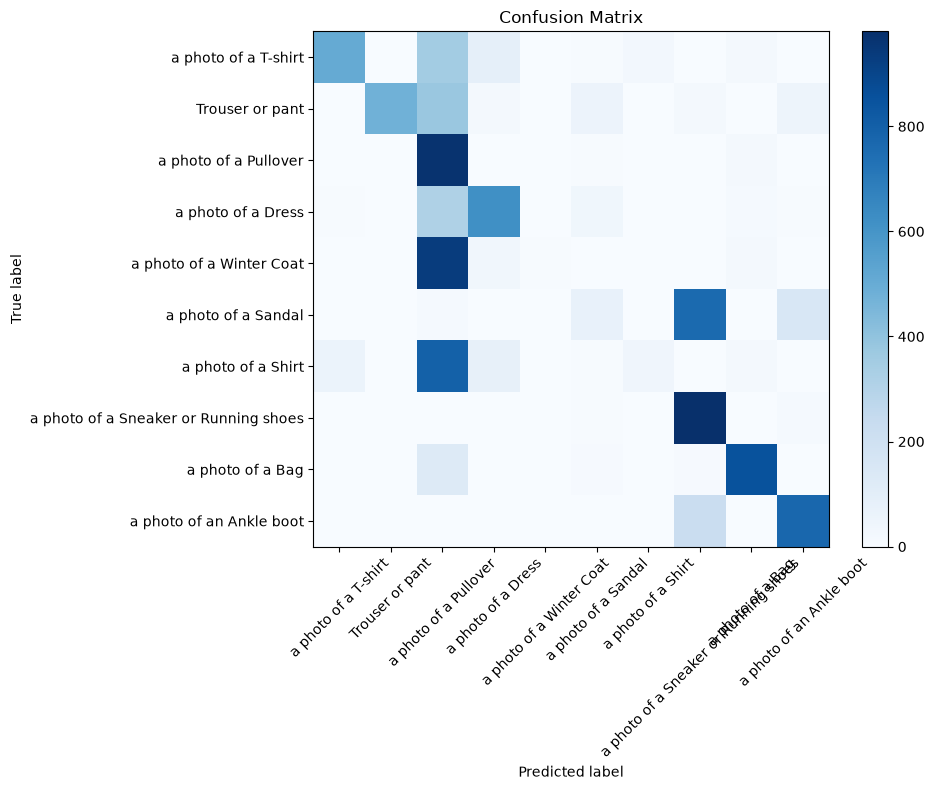

In [9]:
IMPROVED_CLASS_NAMES = [
    "a photo of a T-shirt",
    "Trouser or pant",
    "a photo of a Pullover",
    "a photo of a Dress",
    "a photo of a Winter Coat",
    "a photo of a Sandal",
    "a photo of a Shirt",
    "a photo of a Sneaker or Running shoes",
    "a photo of a Bag",
    "a photo of an Ankle boot"
]

improved_classes_text_embeddings = get_text_embeddings(IMPROVED_CLASS_NAMES)

y_true, improved_classes_y_pred = [], []

for pixel_values, labels in test_loader:
    
# Report the accuracy of the predictions
    improved_classes_image_embeddings = get_image_embeddings(pixel_values)
    improved_classes_computed_cosine_similarity = get_cosine_similarity(improved_classes_image_embeddings, improved_classes_text_embeddings)
    improved_classes_predictions = get_predictions(improved_classes_computed_cosine_similarity)
    
    y_true.extend(labels.cpu().numpy())
    improved_classes_y_pred.extend(improved_classes_predictions)
    
# Report the confusion matrix

improved_classes_accuracy = accuracy_score(y_true, improved_classes_y_pred)
print(f'improved_classes zero-shot accuracy: {improved_classes_accuracy:.4f}')

plot_confusion_matrix(y_true, improved_classes_y_pred, IMPROVED_CLASS_NAMES)

Yes, it did. I changed the class names to those and it got worse, the accuracy became 0.5294.

Then, let's reverse the class names back to initially what they were before,

CLASS_NAMES = [

    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]


 easy and simple class names. If it gets improved then it shows zero-shot baseline works better with short preferably one word class names.

improved_classes zero-shot accuracy: 0.6240


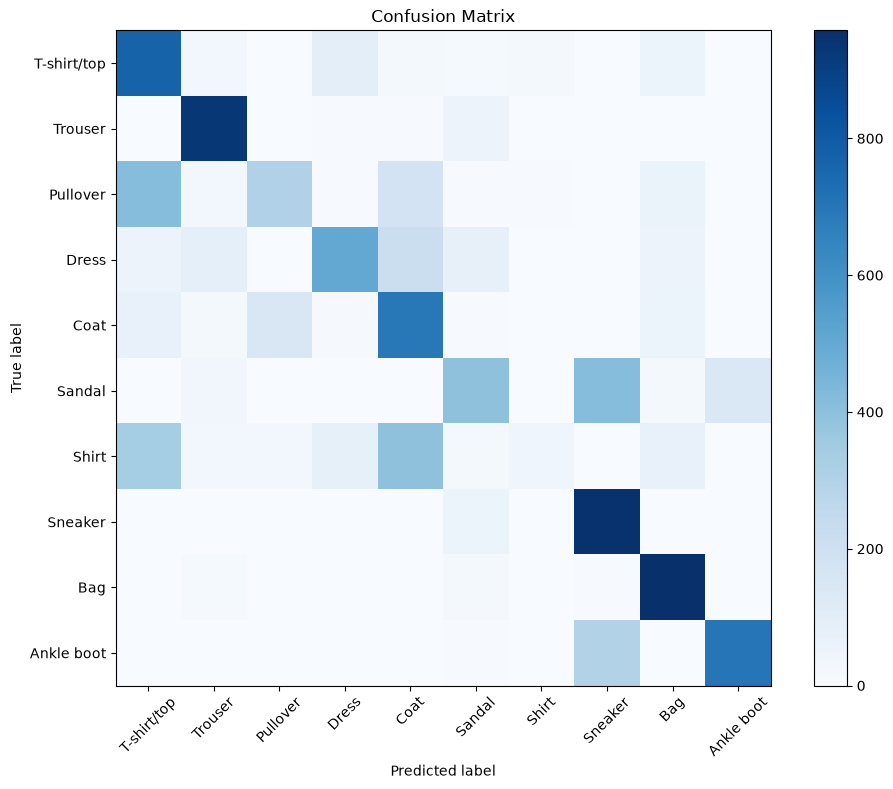

In [10]:
CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

improved_classes_text_embeddings = get_text_embeddings(CLASS_NAMES)

y_true, improved_classes_y_pred = [], []

for pixel_values, labels in test_loader:
    
# Report the accuracy of the predictions
    improved_classes_image_embeddings = get_image_embeddings(pixel_values)
    improved_classes_computed_cosine_similarity = get_cosine_similarity(improved_classes_image_embeddings, improved_classes_text_embeddings)
    improved_classes_predictions = get_predictions(improved_classes_computed_cosine_similarity)
    
    y_true.extend(labels.cpu().numpy())
    improved_classes_y_pred.extend(improved_classes_predictions)
    
# Report the confusion matrix

improved_classes_accuracy = accuracy_score(y_true, improved_classes_y_pred)
print(f'improved_classes zero-shot accuracy: {improved_classes_accuracy:.4f}')

plot_confusion_matrix(y_true, improved_classes_y_pred, CLASS_NAMES)

Actually, shortening the class names did improve the model accuracy, it came back to 0.6240, what it was before at the start of this assignment.

## Visualizing Image Embeddings with UMAP

To better understand how the model perceives the different classes, we can visualize the image embeddings using UMAP (Uniform Manifold Approximation and Projection). UMAP is a dimensionality reduction technique that helps us see how similar or dissimilar the embeddings are in a lower-dimensional space.

By visualizing the embeddings, we can gain insights into how well the model can distinguish certain images, even without considering the text prompts. This can help us identify clusters of similar images and see if there are any overlaps between classes.

You should:

- [ ] Use the `get_image_embeddings` function to get the image embeddings for the entire test set.
- [ ] Use UMAP to reduce the dimensionality of the image embeddings to 2D.
- [ ] Plot the 2D embeddings, coloring each point by its true class label.

You may need to install the `umap-learn` library if you haven't already. You can do this by running `pip install umap-learn`.

In [11]:
# Uncomment the following line to install UMAP if you haven't already
# !pip install umap-learn

Embeddings shape: (10000, 512)
Labels shape: (10000,)


/home/myos/Desktop/DSI/MLF1/deep_learning/deep-learning-env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/myos/Desktop/DSI/MLF1/deep_learning/deep-learning-env/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


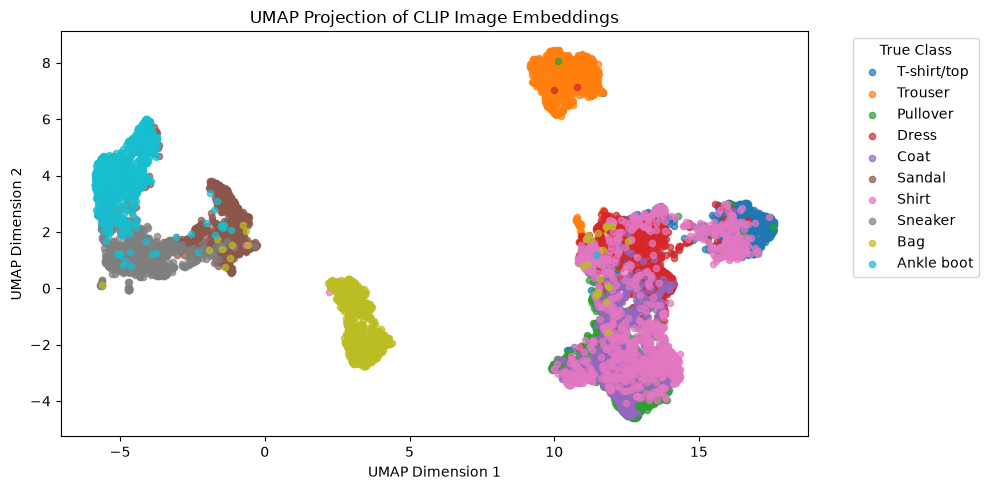

In [12]:
from umap import UMAP
from tqdm import tqdm

# ------------------------------------------------------------
# 1. Collect image embeddings
# ------------------------------------------------------------
all_img_emb = []
all_labels  = []

for pixel_values, labels in test_loader: 
    image_embs = get_image_embeddings(pixel_values)
    all_img_emb.append(image_embs.cpu())
    all_labels.append(labels.cpu())
    
all_img_emb = torch.cat(all_img_emb, dim=0)
all_labels = torch.cat(all_labels, dim=0)

embeddings_np = all_img_emb.numpy()
labels_np = all_labels.numpy()

print(f'Embeddings shape: {embeddings_np.shape}')
print(f'Labels shape: {labels_np.shape}')
# ------------------------------------------------------------
# 2. Fit UMAP
# ------------------------------------------------------------
reduced_emb_dim = UMAP(n_components=2, metric='cosine', random_state=42).fit_transform(embeddings_np) # cosine better matches my model analysis

# ------------------------------------------------------------
# 3. Plot coloured by ground-truth label
# ------------------------------------------------------------
plt.figure(figsize=(10, 5))
for class_idx, class_name in enumerate(CLASS_NAMES):
    class_mask = labels_np == class_idx
    plt.scatter(
        reduced_emb_dim[class_mask, 0],
        reduced_emb_dim[class_mask, 1],
        label=class_name,
        alpha=0.7, 
        s=20
    )
plt.title("UMAP Projection of CLIP Image Embeddings")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend(title="True Class", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [13]:
import plotly.graph_objects as go

fig = go.Figure()

for class_idx, class_name in enumerate(CLASS_NAMES):
    class_mask = labels_np == class_idx

    fig.add_trace(
        go.Scatter(
            x=reduced_emb_dim[class_mask, 0],
            y=reduced_emb_dim[class_mask, 1],
            mode="markers",
            name=class_name,
            marker=dict(
                size=7,
                opacity=0.7
            )
        )
    )
fig.update_layout(
    title="UMAP visualization of image embeddings",
    xaxis_title="UMAP dimension 1",
    yaxis_title="UMAP dimension 2",
    width=1000,
    height=500,
    legend_title="True class",
    template="plotly_white"
)

fig.show()

The UMAP embeddings allow us to see how separable or non-separable different classes are with our specific model. If two specific images are very similar, then they will be placed near each other on this graph. 

Reflection: Do you notice any challenges in distinguishing images based on this figure? Are there any types of clothing in the dataset which the model has no trouble distinguishing from the others?

## My Answer:
Yes, Coat, Shirt, Dress, Pullover, T-shirt/Top, some of Bags, and some Trouser are overlapping, it's hard to distinguish the borderline between them.
Also, Most of Ankle-boot Sandal and Sneaker are very close but it's possible to somewhat separate the location of most of them.

Yes, clearly most of bags are located at the center point of the image.
Also, most of Trousers are located at the top right corner of the image.



## Mini-Experiment

In this section, you will conduct a mini-experiment of your choice to further explore the capabilities of zero-shot classification with transformers. This can be anything you'd like, but here are some ideas to get you started.

### A. Alternative Model

So far we have been utilizing OpenAI's CLIP model for zero-shot classification. However, there are many other vision–language models available in the `transformers` library that you can experiment with. For example, there are larger CLIP models such as [clip-vit-large-patch14](https://huggingface.co/openai/clip-vit-large-patch14), and open-source versions such as [laion/CLIP-ViT-B-32-laion2B-s34B-b79K](https://huggingface.co/laion/CLIP-ViT-B-32-laion2B-s34B-b79K). You can also search huggingface [here](https://huggingface.co/models?sort=trending&search=clip) to find other models that might be suitable for zero-shot classification.

You can try using a different model to see if it improves the zero-shot classification performance. You should:
- [ ] Load a different model and processor from the `transformers` library.
- [ ] Run the zero-shot classification baseline with the new model and report the accuracy and confusion matrix.
- [ ] Reflect on the performance of the new model compared to the original CLIP model
  - How does the new model perform compared to the original CLIP model?
  - Do you notice any differences in the types of errors made by the new model?

### B. Multiple-Description Classification

Another interesting experiment is to explore multiple-description classification. *This involves providing multiple text prompts for each class, allowing the model to choose the most relevant one. For example, instead of just "T-shirt/top", you could provide "a photo of a T-shirt", "a photo of a top", and "a photo of a shirt". This can help the model better understand the class and increases the likelihood of a correct prediction. You should:

- [ ] Create a list of multiple prompts for each class.
- [ ] Use the `get_text_embeddings` function to create text embeddings for the multiple prompts.
- [ ] Run the zero-shot classification baseline again using the multiple prompts and report the accuracy and confusion matrix.
- [ ] Consider the model to be correct if it guesses *any* of the prompts belonging to the correct class.

### C. Top-K Classification

In some classification tasks, it can be useful to consider if the right answer is among the top K (e.g. top 3) predictions. This can be particularly useful in cases where the model is uncertain or when there are multiple similar classes. You should:

- [ ] Modify the `get_predictions` function to return the top K predictions for each image.
- [ ] Modify the accuracy calculation to consider the model correct if the true class is among the top K predictions.
- [ ] Report the accuracy and confusion matrix for the top K predictions. Report at least two different values of K (e.g. K=2 and K=4).

### D. Other Ideas

You are welcome to come up with your own mini-experiment! Explain your idea in the report and implement it. Did it work as you expected? What did you learn from it?

## My Answer:
I'll go with A. Alternative Model

As in lab-4, I didn't like the accuracy of classificaiton of my cat images, because there weren't enough time to fine-tune the model ResNet50. I increased the count of those pictures with previous cats and dogs pictures I had from before and did the below mini-experiment.

Below, I want to classify animal images with a powerful model like "openai/clip-vit-large-patch14". I used the snippet they provided on its HuggingFace page with some changes.
https://huggingface.co/openai/clip-vit-large-patch14


accuracy: 1.00


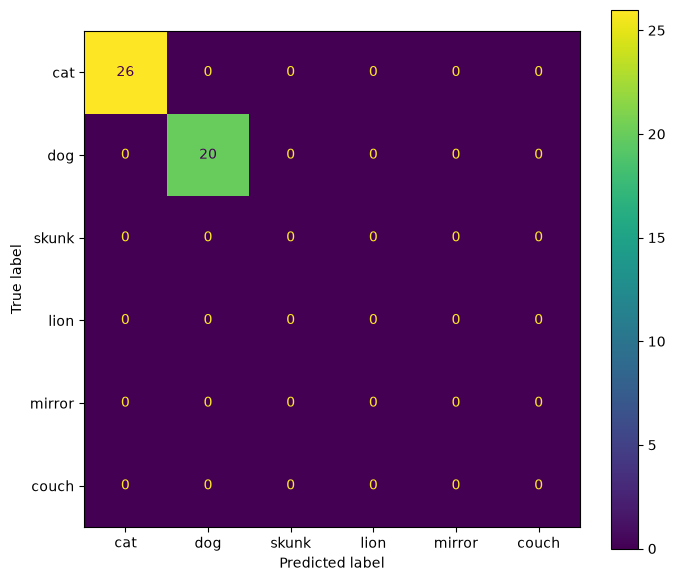

In [15]:
from PIL import Image
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from transformers import CLIPProcessor, CLIPModel
import os
import pandas as pd

model_name = "openai/clip-vit-large-patch14" # The original model name
model = CLIPModel.from_pretrained(model_name) # Loading the model
processor = CLIPProcessor.from_pretrained(model_name) # Loading its processor

photos_label_pairs = [] # Defining a list to relate photos to labels

for filename in os.listdir("animals"): # Iterating over the filenames in animals folder, I already designed the folder content to be pictures with the names I chose.
    
    if "cat" in filename or "Bobo" in filename: # If the filename includes word "cat" or "Bobo", the true animal(s) in the picture is(are) a cat(s).
        photos_label_pairs.append((filename, "cat")) # Relating the filename and its label as a tuple and adding it to the photo_label_pairs list.
        
    elif "dog" in filename: # If the filename includes word "dog" the true animal(s) in the picture is/are dog(s).
        photos_label_pairs.append((filename, "dog")) # Relating the filename and its label as a tuple and adding it to the photo_label_pairs list.

true_labels = [true_label for _, true_label in photos_label_pairs] # extracting true labels as a separate variable true_labels for future processing

class_names = ["cat", "dog", "skunk", "lion", "mirror", "couch"] # Defining class names

prompts = [f"a photo of a {label}" for label in class_names] # Defining prompts for each class name and saving it as a list in prompts variable.

predicted_labels = [] # Defining predicted_labels list
results = [] # Defining results list

for photo, true_label in photos_label_pairs: # Iterating over the tuples in photos_label_pairs list

    image_path = os.path.join("animals", photo) # Defining the image path
    image = Image.open(image_path).convert("RGB") # Opening the image using Image module and converting it into 3 layers of Red, Green, and Blue

    inputs = processor(text=prompts, images=image, return_tensors="pt", padding=True) # Using the processor module from CLIP to relate each image to its text (label) effectively making a dictionary of them.

    with torch.inference_mode():
        outputs = model(**inputs) # It sends the inputs through CLIP model, **inputs expands that dictionary.
        probs = outputs.logits_per_image.softmax(dim=1) # Retrieving the image-to-text similarity scores.
    
    predicted_index = probs.argmax(dim=1).item() # Considering the highest similarity score index as the proper score for the item and saving them in predicted_index variable.
    predicted_label = class_names[predicted_index] # Considering a label for each item according to its relative class name.
    confidence = probs[0, predicted_index].item() # Extracting the confidence(probability) scores for each predicted_index and relating it to the item.
    
    predicted_labels.append(predicted_label) # Adding those predicted labels to the predicted_labels list.
    
    results.append({"photo":photo,   # Making a dictionary of information for each file having the photo filename, its true_label, its predicted label, and the relative confidence score how surely the prediction has been done correctly.
                    "true_label": true_label,
                    "predicted_label": predicted_label,
                    "confidence": confidence})
    
results_df = pd.DataFrame(results) # Making a dataframe of results for future comparison(observation)

accuracy = accuracy_score(true_labels, predicted_labels) # Deriving the accuracy_score of the model by comparing the predicted_labels with the true_labels and printing it.
print(f"accuracy: {accuracy:.2f}")

cm = confusion_matrix(true_labels, predicted_labels, labels=class_names) # Making a confusion_matrix of true_labels and predicted_labels having class_names as the rubric
    
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names) # Displaying the confusion matrix using ConfusionMatrixDisplay module

fig, ax = plt.subplots(figsize=(8, 7)) # Initializing the figure from Matplotlib

display.plot(ax=ax) # Displaying the plot on the figure


In [16]:
results_df

,photo,true_label,predicted_label,confidence
0,dog (14).jpg,dog,dog,0.995737
1,Bobo3.jpg,cat,cat,0.987573
2,dog (11).jpg,dog,dog,0.987714
3,dog (7).jpg,dog,dog,0.899341
4,dog (8).jpg,dog,dog,0.987058
5,Bobo2.jpg,cat,cat,0.988367
6,cat (4).jpg,cat,cat,0.967483
7,Bobo6.jpg,cat,cat,0.973424
8,cat (19).jpg,cat,cat,0.974908
9,cat (5).jpg,cat,cat,0.996350


### Short Report

In this section, you will write a short report summarizing your findings from the mini-experiment. The report should include the following sections:

- **Introduction**: Briefly describe the mini-experiment you conducted and its objectives.
- **Methodology**: Explain the steps you took to conduct the experiment, including any modifications you made to the code or model.
- **Results**: Present the results of your experiment.
- **Discussion**: Reflect on the performance of the model and the implications of your findings. Consider the strengths and weaknesses of zero-shot transformers versus a trained CNN.

## My Answer:

### Introduction:
This mini-experiment is supposed to classify animal pictures using an advanced algorithm available that my current resources can handle it.

### Methodology:
I received the original code from HUGGINGFACE and altered it making it suitable for this specific mini-experiment use case.

Just to have a quick recap of what this original model does:
Contrastive Language-Image Pretraining (CLIP) is a multimodal model capable of processing images and text together. It can understand the relationship between images and textual descriptions, allowing it to perform tasks such as image classification based on Natural Language labels.

##### The steps:
First I imported the required libraries:
- Image module from PIL package to transform each image to its RGB layers and make it digestable by the model.
- Scikit-Learn metrics:
  - Accuracy_score module to calculate final accuracy of the predictions.
  - Confusion_matrix to report both correct classifications and the specific incorrect class combinations.
  - ConfusionMatrixDisplay to make the confusion_matrix displayable in a figure.
- CLIPProcessor and CLIPModel modules from transformers to receive the model and its processor for this experiment.
- OS module for os processes.
- I made a list of tuples containing the name of each animal with its true label.
- Extracted those true_labels for future processing (in accuracy_score and confusion_matrix calculations)
- Made a list of class_names, a list of prompts for each class, and lists of predicted labels and results.
- Iterated in photos_label_pairs to analyze each picture with its label:
  - Defined the image path and converted each image to its RGB channels.
  - Use processor module to relate each image to its label as a dictionary.
  - Used PyTorch prediction to use CLIP model and derive image-to-text similarity scores for each image and its label.
  - Extracted the maximum probability score index for each image and extracted the respective class names and calculated the confidence score for each image.
  - Collected the predicted_labels and results filenames, the true labels, predicted labels, and confidence scores.
- Made a pandas DataFrame of filenames, the true labels, predicted labels, and confidence scores.
- Calculated the accuracy_score and confusion matrix and displayed the confusion matrix.

### Results:
Results are extraordinary well and adequate. I was shocked to see this much accurate prediction. 26 cats and 20 dogs, exactly the same as the true labels in the dataset.

### Discussion:
The performance of the model was extra-ordinary well in this mini-experiment, though further analysis with massive dataset is needed to conclude how well the model predicts items in pictures.

Further approaches through this experiment can be providing tricky pictures to the model (even by shooting specific photos, e.g. photos of a cat with black hair only showing its eyes, nose, and mouth.) to see how accurate it can predict the contents (in this case animals) in each picture.

Zero-shot transformers have great potential against CNNs, in just 40 lines of code I have made a model which predicts items (in this case animals) in pictures. The model was pre-trained and I only defined my interested class_names to it by my own choice, so I spent $0 on pre-training this extraordinary model and it predicted the correct labels very well. 
The weaknesses of this Zero-shot transformer can be if the model performs inadequately I have no access to edit the model not only by its layers but also I can not efficiently train this large model.
The model is generalized and to the extent of this mini-experiment performs very well in predicting correct labels.

Though in case of designing my own CNN. I had to spend a lot of time to tweak the model parameters despite having limited resources to fascilitate such training. But, If I had done so I could design a model which was specifically trained for this mini-experiment and could predict only animals in pictures. Though it's performance could be not reliable.

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 02/11/2025`
* The branch name for your repo should be: `assignment-2`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_2.ipynb)
    * The Lab 4 notebook (labs/lab_4.ipynb)
    * The Lab 5 notebook (labs/lab_5.ipynb)
    * The Lab 6 notebook (labs/lab_6.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-7-help-ml`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.